<a href="https://colab.research.google.com/github/doroteatomic/white-balancing-algorithms/blob/main/white_balancing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Instalacija i učitavanje dataset-a

In [1]:
!pip install kaggle

In [2]:
!wget https://zenodo.org/record/4153431/files/SimpleCube++.zip

--2026-03-19 13:00:12--  https://zenodo.org/record/4153431/files/SimpleCube++.zip
Resolving zenodo.org (zenodo.org)... 137.138.52.235, 188.185.43.153, 188.184.98.114, ...
Connecting to zenodo.org (zenodo.org)|137.138.52.235|:443... connected.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/4153431/files/SimpleCube++.zip [following]
--2026-03-19 13:00:13--  https://zenodo.org/records/4153431/files/SimpleCube++.zip
Reusing existing connection to zenodo.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 2113441199 (2.0G) [application/octet-stream]
Saving to: ‘SimpleCube++.zip’

SimpleCube++.zip    100%[===================>]   1.97G  31.9MB/s    in 67s     

2026-03-19 13:01:20 (30.1 MB/s) - ‘SimpleCube++.zip’ saved [2113441199/2113441199]



In [3]:
!unzip SimpleCube++.zip "SimpleCube++/test/*"

Archive:  SimpleCube++.zip
   creating: SimpleCube++/test/
   creating: SimpleCube++/test/PNG/
  inflating: SimpleCube++/test/PNG/04_9463.png  
  inflating: SimpleCube++/test/PNG/00_2291.png  
  inflating: SimpleCube++/test/PNG/00_0126.png  
  inflating: SimpleCube++/test/PNG/20_3090.png  
  inflating: SimpleCube++/test/PNG/03_9193.png  
  inflating: SimpleCube++/test/PNG/00_0535.png  
  inflating: SimpleCube++/test/PNG/01_7820.png  
  inflating: SimpleCube++/test/PNG/00_0072.png  
  inflating: SimpleCube++/test/PNG/00_2382.png  
  inflating: SimpleCube++/test/PNG/08_0041.png  
  inflating: SimpleCube++/test/PNG/00_1701.png  
  inflating: SimpleCube++/test/PNG/00_1150.png  
  inflating: SimpleCube++/test/PNG/00_0444.png  
  inflating: SimpleCube++/test/PNG/00_2652.png  
  inflating: SimpleCube++/test/PNG/17_1663.png  
  inflating: SimpleCube++/test/PNG/02_8087.png  
  inflating: SimpleCube++/test/PNG/00_1069.png  
  inflating: SimpleCube++/test/PNG/17_1696.png  
  inflating: SimpleCube

In [4]:
!cp -r SimpleCube++/test .

In [5]:
import numpy as np
import cv2
import pandas as pd
import os
import matplotlib.pyplot as plt
from tqdm import tqdm

In [6]:
print(os.listdir("test"))

['PNG', 'gt.csv']


In [7]:
gt = pd.read_csv("test/gt.csv")
gt.head()

,image,mean_r,mean_g,mean_b
0,00_0010,0.386447,0.459644,0.153909
1,00_0011,0.199302,0.469274,0.331424
2,00_0019,0.200418,0.469753,0.329829
3,00_0046,0.196287,0.463259,0.340454
4,00_0057,0.201047,0.469470,0.329483


In [8]:
gt_dict = {}

for _, row in gt.iterrows():

    filename = row["image"] + ".png"

    gt_dict[filename] = np.array([
        row["mean_r"],
        row["mean_g"],
        row["mean_b"]
    ])

In [9]:
print(gt_dict["00_0010.png"])

[0.38644711 0.45964391 0.15390897]


In [10]:
import cv2

img = cv2.imread("test/PNG/1.png")

# 3. Gray World algoritam

In [11]:
def gray_world(image):

    img = image.astype(np.float32)

    R = np.mean(img[:,:,2])
    G = np.mean(img[:,:,1])
    B = np.mean(img[:,:,0])

    illum = np.array([R, G, B])

    return illum

Iluminant predstavlja prosjek RGB kanala.

# 4. Shades of Gray algoritam

In [12]:
def shades_of_gray(image, p=6):

    img = image.astype(np.float32)

    R = np.mean(img[:,:,2]**p)**(1/p)
    G = np.mean(img[:,:,1]**p)**(1/p)
    B = np.mean(img[:,:,0]**p)**(1/p)

    illum = np.array([R, G, B])

    return illum

Iluminant je ovdje p-norma kanala. Najčešće p = 6.

# 5. White balance korekcija

In [13]:
def white_balance(image, illum):

    img = image.astype(np.float32)

    illum = illum / np.linalg.norm(illum)

    scale = 1 / illum

    balanced = img.copy()
    balanced[:,:,2] *= scale[0]
    balanced[:,:,1] *= scale[1]
    balanced[:,:,0] *= scale[2]

    balanced = np.clip(balanced,0,255)

    return balanced.astype(np.uint8)

White Balance korekcija

Nakon procjene iluminanta potrebno je korigirati RGB vrijednosti slike kako bi iluminant postao neutralan. Korekcija se provodi prema formuli:

$$
I_{corrected} = I \cdot \frac{avg}{illum}
$$

gdje je:

- $I$ — originalna vrijednost piksela  
- $I_{corrected}$ — korigirana vrijednost piksela  
- $illum = (R, G, B)$ — procijenjeni iluminant  
- $avg$ — prosječna vrijednost iluminanta  

Prosjek iluminanta računa se kao:

$$
avg = \frac{R + G + B}{3}
$$

Na taj način skaliraju se RGB kanali slike tako da iluminant postane neutralno bijel, čime se uklanja dominantna boja osvjetljenja iz slike.

# 6. Angular error (evaluacija)

In [14]:
def angular_error(est, gt):

    est = est / np.linalg.norm(est)
    gt = gt / np.linalg.norm(gt)

    dot = np.clip(np.dot(est, gt), -1, 1)

    angle = np.arccos(dot)

    return np.degrees(angle)

Za evaluaciju algoritama koristi se **kutna pogreška (angular error)** između procijenjenog iluminanta i stvarnog iluminanta iz dataset-a.

Formula je:

$$
error = \arccos \left( \frac{E_{est} \cdot E_{gt}}{|E_{est}| \, |E_{gt}|} \right)
$$

gdje je:

- $E_{est}$ — procijenjeni iluminant  
- $E_{gt}$ — stvarni (ground truth) iluminant iz dataset-a  
- $E_{est} \cdot E_{gt}$ — skalarni produkt vektora  
- $|E_{est}|$ i $|E_{gt}|$ — norme (duljine) vektora

Rezultat predstavlja kut između dva RGB vektora iluminanta u stupnjevima. Što je kut manji, to je procjena iluminanta točnija.

In [15]:
image_folder = "/content/SimpleCube++/test/PNG"

gw_errors = []
sg_errors = []

for filename in tqdm(os.listdir(image_folder)):

    if filename.endswith(".png"):

        path = os.path.join(image_folder, filename)

        img = cv2.imread(path)

        gt_illum = gt_dict[filename]

        gw_est = gray_world(img)
        sg_est = shades_of_gray(img, p=6)

        gw_errors.append(angular_error(gw_est, gt_illum))
        sg_errors.append(angular_error(sg_est, gt_illum))

100%|██████████| 462/462 [00:17<00:00, 25.91it/s]


In [16]:
print("Gray World mean angular error:", np.mean(gw_errors))
print("Shades of Gray mean angular error:", np.mean(sg_errors))

Gray World mean angular error: 12.370657719570824
Shades of Gray mean angular error: 9.684309714883529


In [35]:
import cv2
import numpy as np

def apply_wb_and_display(path, illum_est):
    image = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    image = image.astype(np.float32)


    image = image / 65535.0


    illum_est = illum_est / np.linalg.norm(illum_est)
    image_wb = image / illum_est


    image_wb = np.clip(image_wb, 0, 1)


    gamma = 1 / 2.2
    image_wb = image_wb ** gamma

    image_display = (image_wb * 255).astype(np.uint8)

    return image_display

In [36]:
import cv2
import numpy as np

def load_image(path):
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    img = img.astype(np.float32) / 65535.0
    return img

def gray_world_illum(image):
    return np.mean(image, axis=(0,1))

def shades_of_gray_illum(image, p=6):
    illum = np.power(np.mean(np.power(image, p), axis=(0,1)), 1/p)
    return illum

def apply_wb(image, illum):
    illum = illum / np.linalg.norm(illum)
    img_wb = image / illum
    img_wb = np.clip(img_wb, 0, 1)


    img_wb = img_wb ** (1/2.2)

    return (img_wb * 255).astype(np.uint8)

In [37]:
image = load_image(path)


gw_illum = gray_world_illum(image)
sg_illum = shades_of_gray_illum(image)


img_gw = apply_wb(image, gw_illum)
img_sg = apply_wb(image, sg_illum)


img_orig = apply_wb(image, np.array([1,1,1]))

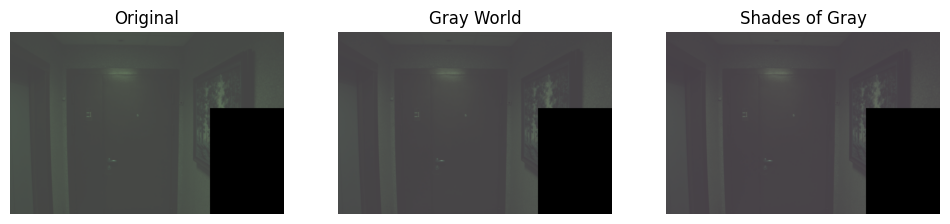

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(img_orig)
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Gray World")
plt.imshow(img_gw)
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Shades of Gray")
plt.imshow(img_sg)
plt.axis('off')

plt.show()

In [38]:
import os
import random
import matplotlib.pyplot as plt

def show_multiple_results(image_paths, n=5):
    selected = random.sample(image_paths, n)

    plt.figure(figsize=(12, 4*n))

    for i, path in enumerate(selected):
        image = load_image(path)

        gw_illum = gray_world_illum(image)
        sg_illum = shades_of_gray_illum(image)

        img_orig = apply_wb(image, np.array([1,1,1]))
        img_gw = apply_wb(image, gw_illum)
        img_sg = apply_wb(image, sg_illum)

        plt.subplot(n, 3, 3*i + 1)
        plt.imshow(img_orig)
        plt.title("Original")
        plt.axis('off')

        plt.subplot(n, 3, 3*i + 2)
        plt.imshow(img_gw)
        plt.title("Gray World")
        plt.axis('off')

        plt.subplot(n, 3, 3*i + 3)
        plt.imshow(img_sg)
        plt.title("Shades of Gray")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [31]:
test_folder = "/content/SimpleCube++/test/PNG"

In [33]:
image_paths = [os.path.join(test_folder, f) for f in os.listdir(test_folder) if f.endswith(".png")]

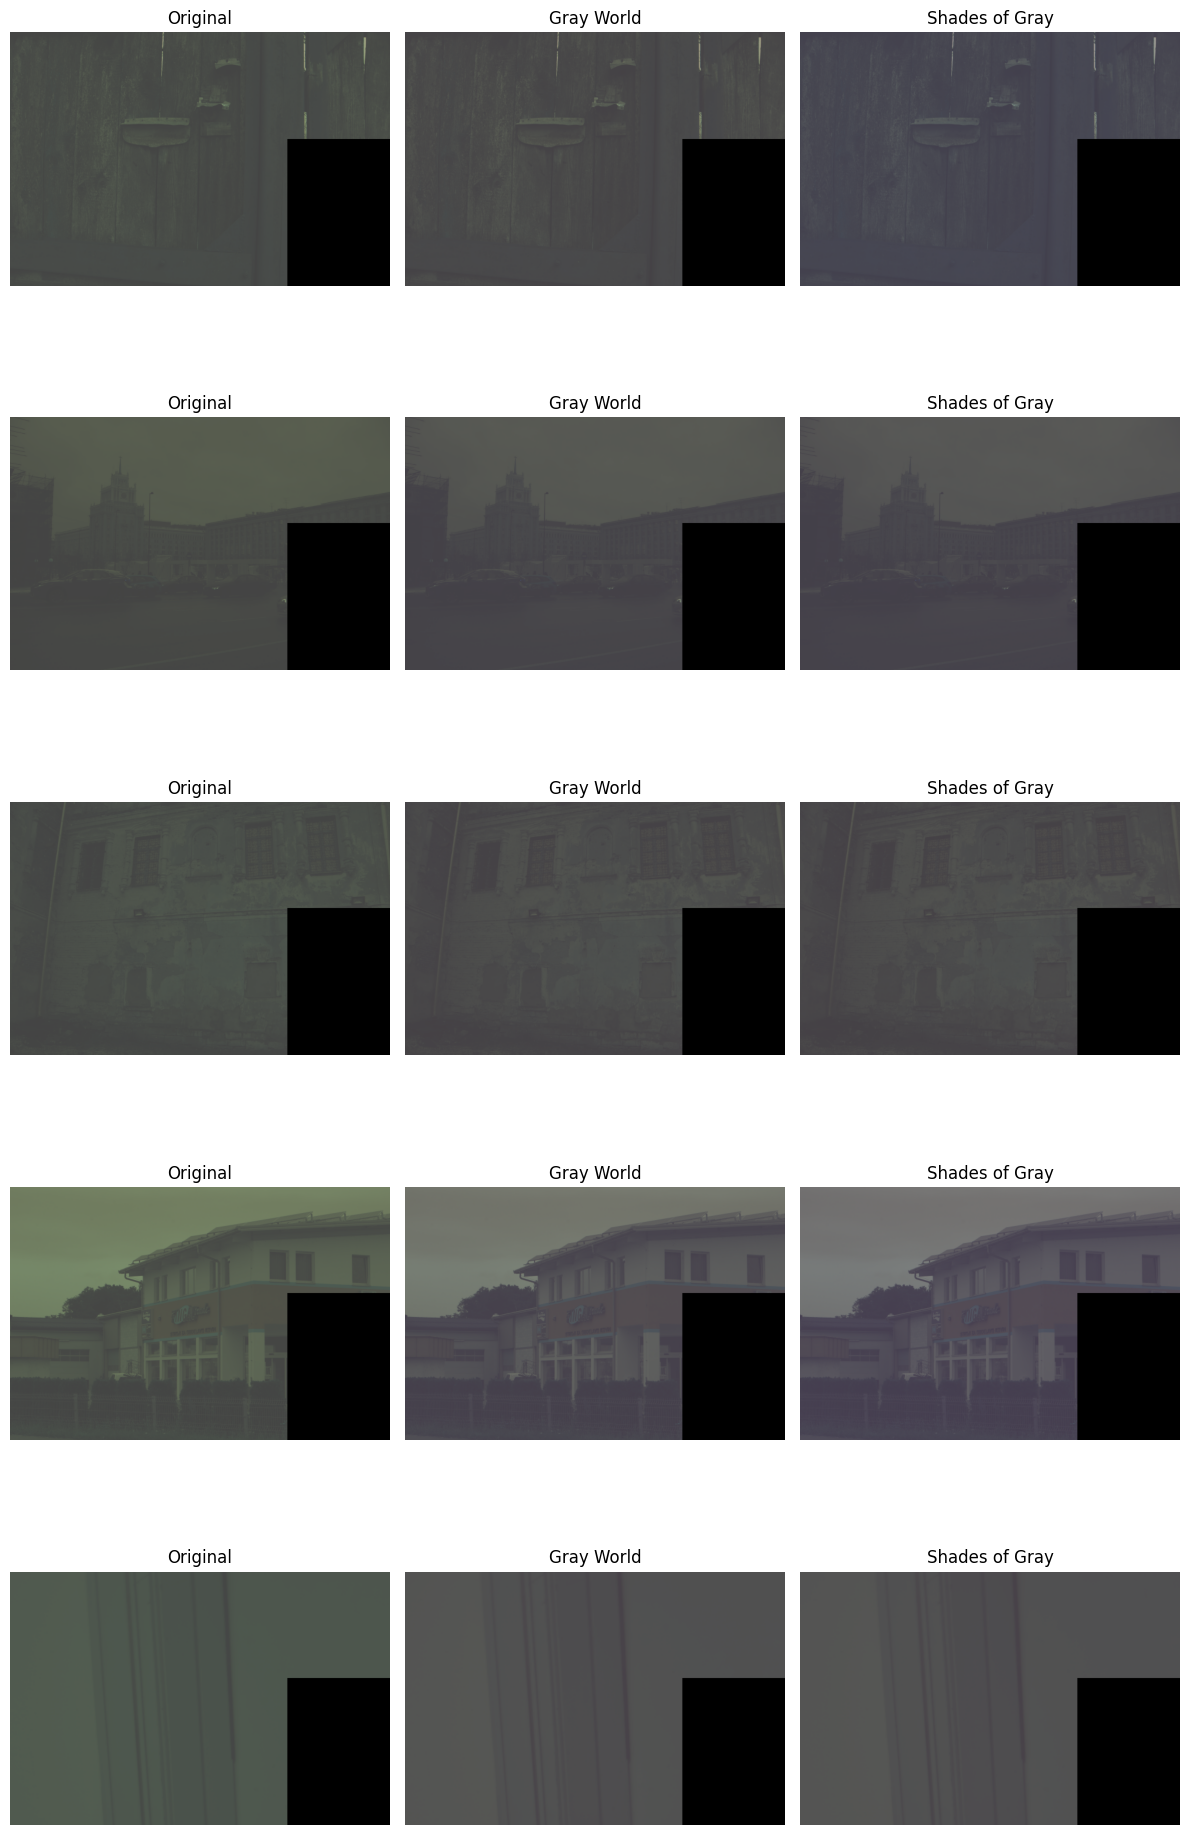

In [40]:
show_multiple_results(image_paths, n=5)

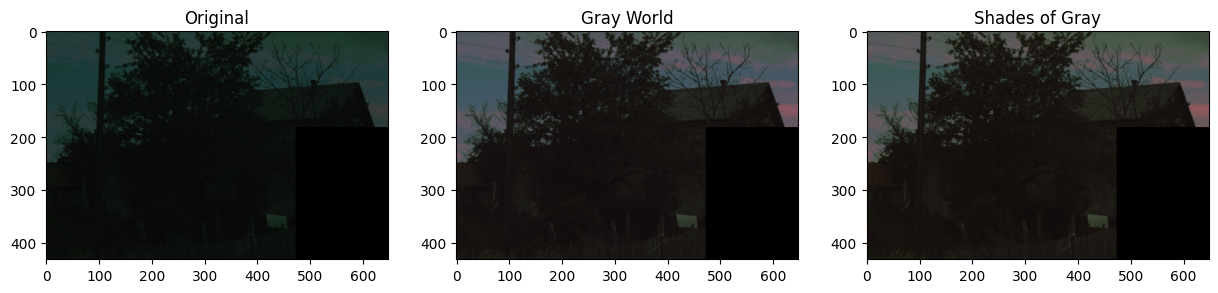

In [17]:
img = cv2.imread("/content/SimpleCube++/test/PNG/00_0011.png")

gw = gray_world(img)
sg = shades_of_gray(img)

img_gw = white_balance(img, gw)
img_sg = white_balance(img, sg)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(img_gw, cv2.COLOR_BGR2RGB))
plt.title("Gray World")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(img_sg, cv2.COLOR_BGR2RGB))
plt.title("Shades of Gray")

plt.show()

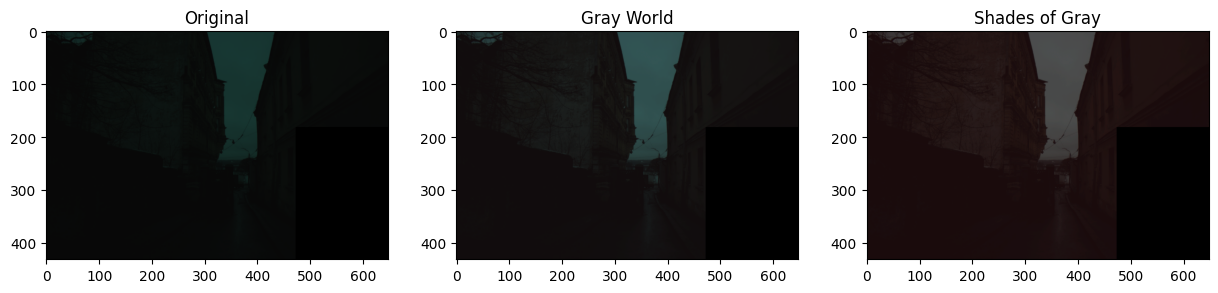

In [18]:
img = cv2.imread("/content/SimpleCube++/test/PNG/02_8262.png")

gw = gray_world(img)
sg = shades_of_gray(img)

img_gw = white_balance(img, gw)
img_sg = white_balance(img, sg)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(img_gw, cv2.COLOR_BGR2RGB))
plt.title("Gray World")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(img_sg, cv2.COLOR_BGR2RGB))
plt.title("Shades of Gray")

plt.show()

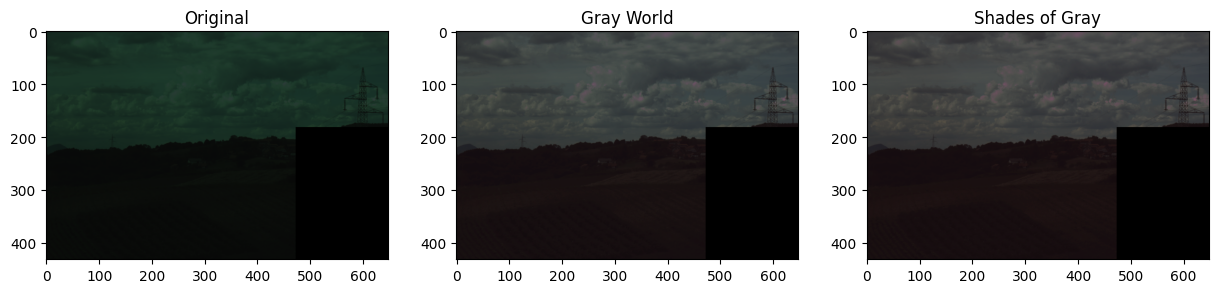

In [19]:
img = cv2.imread("/content/SimpleCube++/test/PNG/00_0571.png")

gw = gray_world(img)
sg = shades_of_gray(img)

img_gw = white_balance(img, gw)
img_sg = white_balance(img, sg)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(img_gw, cv2.COLOR_BGR2RGB))
plt.title("Gray World")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(img_sg, cv2.COLOR_BGR2RGB))
plt.title("Shades of Gray")

plt.show()

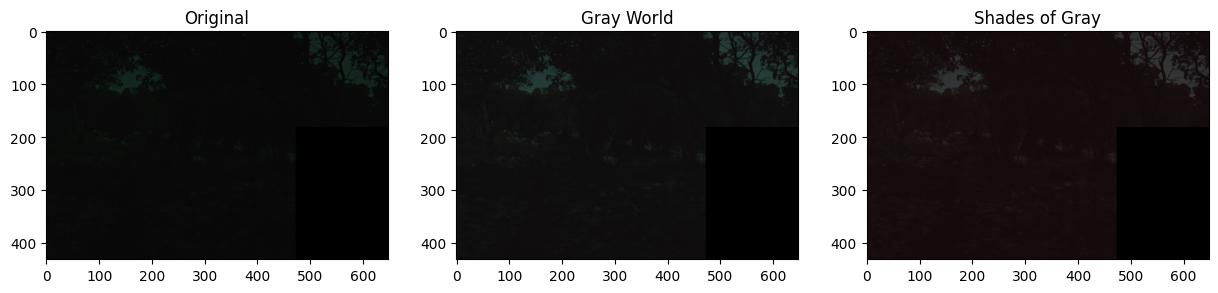

In [20]:
img = cv2.imread("/content/SimpleCube++/test/PNG/04_9717.png")

gw = gray_world(img)
sg = shades_of_gray(img)

img_gw = white_balance(img, gw)
img_sg = white_balance(img, sg)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(img_gw, cv2.COLOR_BGR2RGB))
plt.title("Gray World")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(img_sg, cv2.COLOR_BGR2RGB))
plt.title("Shades of Gray")

plt.show()